In [4]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
def load_token_arrays(token, h5_path="stats.h5"):
    """
    Load all metric arrays for a given token.
    Returns a dict mapping each metric to an array of shape (N, L, H).
    token ∈ {"rel", "A", "B"}.
    """
    assert token in {"rel", "A", "B"}, "Wrong token key!"
    stats = []

    with h5py.File(h5_path, "r") as f:
        scenes = f["scenes"]

        # ---------------------------------------
        # Find metrics for this token from first scene that contains it
        # ---------------------------------------
        metric_names = None
        for scene_id in scenes.keys():
            scene = scenes[scene_id]
            if token in scene:
                metric_names = list(scene[token].keys())
                break
        if metric_names is None:
            raise KeyError(f"Token '{token}' not found in any scene.")

        # Prepare collectors
        collectors = {metric: [] for metric in metric_names}

        # ---------------------------------------
        # Gather (L, H) matrices for each scene
        # ---------------------------------------
        for scene_id in scenes.keys():
            scene = scenes[scene_id]
            if token not in scene:
                continue

            grp = scene[token]
            for metric in metric_names:
                arr = grp[metric][()]     # shape (L, H)
                collectors[metric].append(arr)

        # ---------------------------------------
        # Stack statistics
        # ---------------------------------------
        stacked_stats = {}
        for metric, mats in collectors.items():
            if len(mats) == 0:
                continue

            stack = np.stack(mats, axis=0)  # shape: (num_scenes, L, H)
            stacked_stats[metric] = stack
            
    return stacked_stats

In [6]:
def df_from_metric_dict(metric_dict):
    """
    metric_dict: {
        "<metric_name>": array_of_shape_(N, L, H),
        ...
    }

    Returns a tidy DataFrame:
        scene, layer, head, head_id, metric1, metric2, ...
    """
    # Validate shapes
    shapes = [arr.shape for arr in metric_dict.values()]
    assert all(s == shapes[0] for s in shapes), \
    f"All metric arrays must share the same shape, got: {shapes}"

    N, L, H = shapes[0]

    # ----------------------------------------------------------------------
    # Build universal indices (scene, layer, head, head_id)
    # ----------------------------------------------------------------------
    scenes = np.repeat(np.arange(N), L * H)
    layers = np.tile(np.repeat(np.arange(L), H), N)
    heads  = np.tile(np.arange(H), N * L)
    head_ids = layers * H + heads   # globally unique 0..L*H-1

    # ----------------------------------------------------------------------
    # Build DataFrame
    # ----------------------------------------------------------------------
    df = pd.DataFrame({
        "scene": scenes,
        "layer": layers,
        "head": heads,
        "head_id": head_ids,
    })

    # Add each metric as a column
    for metric_name, arr in metric_dict.items():
        df[metric_name] = arr.reshape(-1)

    return df

In [7]:
rel_metric_dict = load_token_arrays("rel")
print(rel_metric_dict.keys())

dict_keys(['com_relation', 'com_union', 'entropy', 'iou_relation', 'iou_union'])


In [8]:
A_metric_dict = load_token_arrays("A")
print(A_metric_dict.keys())

dict_keys(['com_bbox', 'entropy', 'iou_bbox'])


In [9]:
B_metric_dict = load_token_arrays("B")
print(B_metric_dict.keys())

dict_keys(['com_bbox', 'entropy', 'iou_bbox'])


In [10]:
rel_df = df_from_metric_dict(rel_metric_dict)
rel_df.head()

,scene,layer,head,head_id,com_relation,com_union,entropy,iou_relation,iou_union
0,0,0,0,0,3.884980,2.105033,3.393327,0.024390,0.000000
1,0,0,1,1,4.428272,2.806573,3.040217,0.023810,0.000000
2,0,0,2,2,3.843743,2.229966,3.775753,0.045455,0.000000
3,0,0,3,3,7.632160,7.071057,0.060509,0.444444,0.098765
4,0,0,4,4,3.561824,1.782346,3.594521,0.024390,0.000000


In [15]:
rel_heads = rel_df.groupby("head_id").mean()[["layer", "com_relation", "com_union", "entropy", "iou_relation", "iou_union"]]
rel_heads.info()

<class 'pandas.core.frame.DataFrame'>
Index: 336 entries, 0 to 335
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   layer         336 non-null    float64
 1   com_relation  336 non-null    float64
 2   com_union     336 non-null    float64
 3   entropy       336 non-null    float32
 4   iou_relation  336 non-null    float64
 5   iou_union     336 non-null    float64
dtypes: float32(1), float64(5)
memory usage: 17.1 KB


In [26]:
A_df, B_df = df_from_metric_dict(A_metric_dict), df_from_metric_dict(B_metric_dict)
A_df.head()

,scene,layer,head,head_id,com_bbox,entropy,iou_bbox
0,0,0,0,0,2.678678,4.111861,0.062500
1,0,0,1,1,3.612679,3.691138,0.000000
2,0,0,2,2,2.970479,4.139234,0.045455
3,0,0,3,3,7.905693,0.008912,0.049383
4,0,0,4,4,2.980392,3.693149,0.000000


In [28]:
A_heads = A_df.groupby("head_id").mean()[["com_bbox", "iou_bbox", "entropy"]]
A_heads.rename(columns={col : col + "_A" for col in A_heads}, inplace=True)
A_heads.info()

<class 'pandas.core.frame.DataFrame'>
Index: 336 entries, 0 to 335
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   com_bbox_A  336 non-null    float64
 1   iou_bbox_A  336 non-null    float64
 2   entropy_A   336 non-null    float32
dtypes: float32(1), float64(2)
memory usage: 9.2 KB


In [29]:
B_heads = B_df.groupby("head_id").mean()[["com_bbox", "iou_bbox", "entropy"]]
B_heads.rename(columns={col : col + "_B" for col in B_heads}, inplace=True)
B_heads.info()

<class 'pandas.core.frame.DataFrame'>
Index: 336 entries, 0 to 335
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   com_bbox_B  336 non-null    float64
 1   iou_bbox_B  336 non-null    float64
 2   entropy_B   336 non-null    float32
dtypes: float32(1), float64(2)
memory usage: 9.2 KB


In [56]:
heads_df = pd.concat([rel_heads, A_heads, B_heads], axis=1)
heads_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 336 entries, 0 to 335
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   layer         336 non-null    float64
 1   com_relation  336 non-null    float64
 2   com_union     336 non-null    float64
 3   entropy       336 non-null    float32
 4   iou_relation  336 non-null    float64
 5   iou_union     336 non-null    float64
 6   com_bbox_A    336 non-null    float64
 7   iou_bbox_A    336 non-null    float64
 8   entropy_A     336 non-null    float32
 9   com_bbox_B    336 non-null    float64
 10  iou_bbox_B    336 non-null    float64
 11  entropy_B     336 non-null    float32
dtypes: float32(3), float64(9)
memory usage: 30.2 KB


In [57]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
pca = PCA(n_components=2)

In [58]:
layer_idx = heads_df.pop("layer").astype(int)
layer_idx.info()

<class 'pandas.core.series.Series'>
Index: 336 entries, 0 to 335
Series name: layer
Non-Null Count  Dtype
--------------  -----
336 non-null    int64
dtypes: int64(1)
memory usage: 5.2 KB


In [61]:
heads_scaled = scaler.fit_transform(heads_df)
heads_pca = pca.fit_transform(heads_scaled)

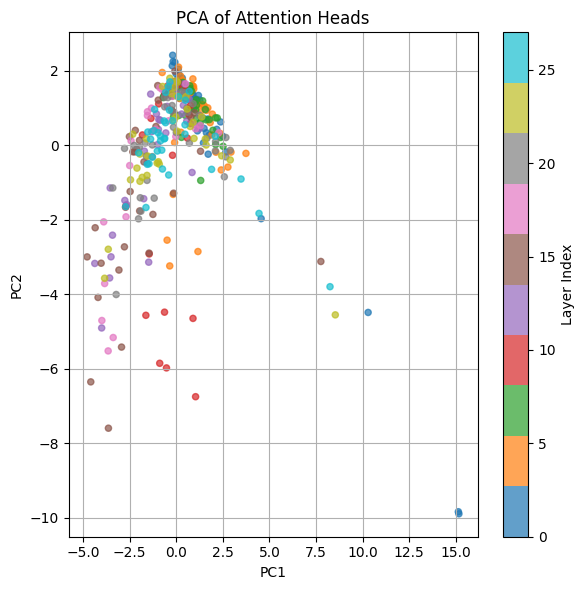

In [66]:
plt.figure(figsize=(6, 6))
sc = plt.scatter(
    heads_pca[:, 0],
    heads_pca[:, 1],
    c=layer_idx,
    cmap="tab10",
    s=20,
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Attention Heads")
plt.colorbar(sc, label="Layer Index")
plt.grid(True)

plt.tight_layout()
plt.savefig("visualizations/heads-pca.png")